In [35]:
import numpy as np
import pandas as pd

In [36]:
data=pd.read_csv('../../outputs/df_engineered.csv', 
                  index_col='datetime', 
                  parse_dates=True)

In [37]:
data.columns

Index(['Temperature', 'Relative Humidity', 'Pressure', 'GHI',
       'Solar Zenith Angle', 'solar_zenith', 'solar_elevation',
       'ET_irradiance', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month',
       'week_of_year', 'day_of_week', 'GHI_lag_1h', 'GHI_lag_3h',
       'GHI_lag_24h', 'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h',
       'humidity_lag_1h', 'humidity_lag_3h', 'humidity_lag_24h',
       'GHI_rollmean_3h', 'GHI_rollmean_6h', 'GHI_rollmean_24h',
       'GHI_rollstd_3h', 'GHI_rollstd_6h', 'GHI_rollstd_24h',
       'cloud_cover_proxy', 'cloud_x_elevation', 'humidity_x_temp'],
      dtype='object')

In [38]:
data.shape

(8736, 33)

In [39]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,8736.0,1.351423e+01,9.179895,-4.800000,6.300000,1.220000e+01,19.900000,39.100000
Relative Humidity,8736.0,6.448296e+01,25.681762,6.510000,43.560000,6.640500e+01,88.012500,100.000000
Pressure,8736.0,9.104106e+02,5.338825,887.000000,907.000000,9.110000e+02,914.000000,923.000000
GHI,8736.0,1.838666e+02,277.334918,0.000000,0.000000,0.000000e+00,323.250000,1031.000000
Solar Zenith Angle,8736.0,8.961240e+01,35.644269,17.650000,62.097500,8.916000e+01,117.312500,162.260000
solar_zenith,8736.0,8.961224e+01,35.644469,17.652544,62.096450,8.915648e+01,117.313572,162.255077
solar_elevation,8736.0,3.877626e-01,35.644469,-72.255077,-27.313572,8.435183e-01,27.903550,72.347456
ET_irradiance,8736.0,3.266501e+02,409.126990,0.000000,0.000000,2.014391e+01,642.318256,1259.616397
hour_sin,8736.0,-8.946852e-18,0.707147,-1.000000,-0.707107,6.123234e-17,0.707107,1.000000
hour_cos,8736.0,-5.530781e-17,0.707147,-1.000000,-0.707107,-6.123234e-17,0.707107,1.000000


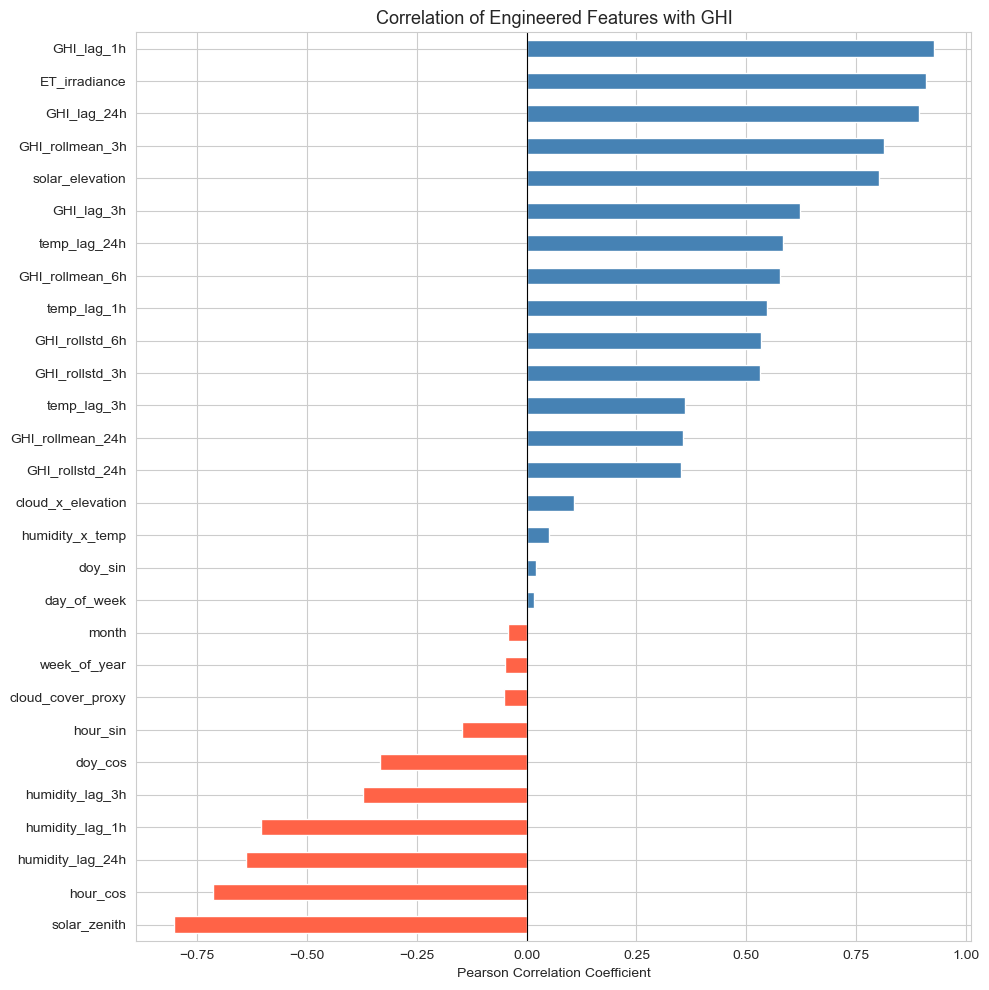

Top 5 positive correlations with GHI:
solar_elevation    0.802
GHI_rollmean_3h    0.814
GHI_lag_24h        0.893
ET_irradiance      0.910
GHI_lag_1h         0.926

Top 5 negative correlations with GHI:
solar_zenith       -0.802
hour_cos           -0.713
humidity_lag_24h   -0.639
humidity_lag_1h    -0.605
humidity_lag_3h    -0.372


In [40]:
import matplotlib.pyplot as plt

# Correlation of each engineered feature with GHI only
cols_engineered = [
    # Task 1 - Solar geometry (3 features)
    'solar_zenith', 
    'solar_elevation', 
    'ET_irradiance',

    # Task 2 - Time features (7 features)
    'hour_sin', 
    'hour_cos', 
    'doy_sin', 
    'doy_cos', 
    'month',
    'week_of_year',
    'day_of_week',

    # Task 3 - Lag features (9 features)
    'GHI_lag_1h', 
    'GHI_lag_3h', 
    'GHI_lag_24h',
    'temp_lag_1h', 
    'temp_lag_3h', 
    'temp_lag_24h',
    'humidity_lag_1h', 
    'humidity_lag_3h', 
    'humidity_lag_24h',

    # Task 4 - Rolling stats (6 features)
    'GHI_rollmean_3h', 
    'GHI_rollmean_6h', 
    'GHI_rollmean_24h',
    'GHI_rollstd_3h',  
    'GHI_rollstd_6h',  
    'GHI_rollstd_24h',

    # Task 5 - Interactions (3 features)
    'cloud_cover_proxy', 
    'cloud_x_elevation', 
    'humidity_x_temp'
]
corr_with_ghi = data[cols_engineered + ['GHI']].corr()['GHI'].drop('GHI').sort_values()

plt.figure(figsize=(10, 10))
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_ghi.values]
corr_with_ghi.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlation of Engineered Features with GHI', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../../Outputs/correlation_with_ghi.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 positive correlations with GHI:')
print(corr_with_ghi.tail(5).round(3).to_string())
print('\nTop 5 negative correlations with GHI:')
print(corr_with_ghi.head(5).round(3).to_string())

In [41]:
# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Created a new column 'Season' by applying the mapping function
data['Season'] = data.index.month.map(get_season)

# Group by 'Season' and sum the GHI values
seasonal_ghi_df = data.groupby('Season')['GHI'].mean().reset_index()

# Display the result
print(seasonal_ghi_df)

   Season         GHI
0    Fall  131.943223
1  Spring  205.612319
2  Summer  305.349185
3  Winter   88.900749


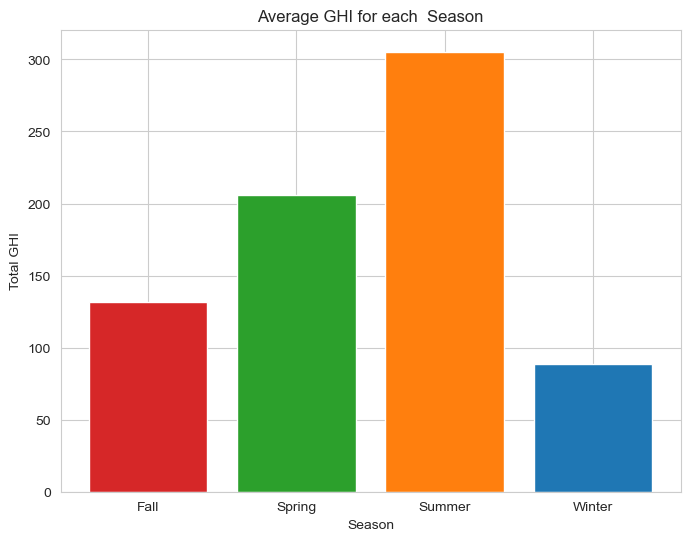

In [42]:

# Define colors for each season
season_colors = {
    'Winter': '#1f77b4',  # blue
    'Spring': '#2ca02c',  # green
    'Summer': '#ff7f0e',  # orange
    'Fall': '#d62728'     # red
}

# Total GHI per season
plt.figure(figsize=(8, 6))
plt.bar(seasonal_ghi_df['Season'], seasonal_ghi_df['GHI'],
        color=[season_colors[season] for season in seasonal_ghi_df['Season']])
plt.xlabel('Season')
plt.ylabel('Total GHI')
plt.title('Average GHI for each  Season')
plt.show()

In [43]:
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable


## Performing ARIMA

In [44]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima
import matplotlib.pyplot as plt



target = data['GHI']

# Stationarity check and differencing if needed
# Differencing to remove trend if the series is non-stationary
target_diff = target.diff().dropna()

# Automatic order selection for ARIMA
auto_model = auto_arima(target_diff, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print("Optimal parameters (p, d, q):", auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=104241.335, Time=8.71 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=106383.769, Time=0.29 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=105029.072, Time=0.57 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=105412.797, Time=1.50 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=104728.858, Time=1.72 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=104781.716, Time=1.94 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=13.11 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=104059.688, Time=12.54 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=104588.494, Time=2.95 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=16.01 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=102511.252, Time=15.51 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=16.45 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=102501.011, Time=20.44 sec
 ARIMA(4,0,4)(0,0,0)[0]             : AIC=inf, Time=21.51 sec
 ARIMA(3,0,5)(0,0,0)[0]   

In [45]:
# --- Train / Test Split ---
split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test  = target.iloc[split_idx:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# --- Fit ARIMA using the order found by auto_arima ---
# auto_arima was run on the differenced series (target_diff), so d=0 here;
# we pass the raw series and let ARIMA handle differencing via the d parameter.
arima_order = auto_model.order          # e.g. (p, d, q)
model      = ARIMA(train, order=arima_order)
model_fit  = model.fit()

print(model_fit.summary())

# --- Forecast on the test period ---
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index             # align timestamps

Train size: 6988, Test size: 1748


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                    GHI   No. Observations:                 6988
Model:                 ARIMA(4, 0, 3)   Log Likelihood              -41658.754
Date:                Tue, 31 Mar 2026   AIC                          83335.509
Time:                        23:12:59   BIC                          83397.176
Sample:                    01-02-2022   HQIC                         83356.760
                         - 10-20-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        213.9828      6.634     32.257      0.000     200.981     226.985
ar.L1          1.8808      0.037     50.931      0.000       1.808       1.953
ar.L2         -1.8813      0.072    -26.292      0.0

Training MAE: 63.93111516058034
Validation MAE: 185.60649839998436


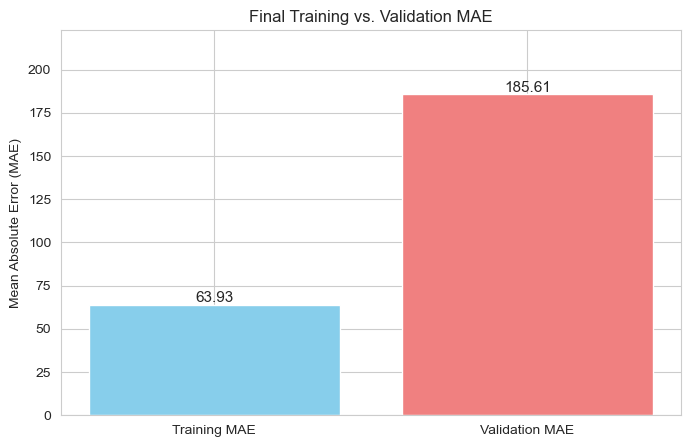

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# 1. Get Training Predictions (to calculate Training MAE)
# This gets the model's "fit" on the data it already saw
train_forecast = model_fit.fittedvalues

# 2. Calculate both MAEs
train_mae = mean_absolute_error(train, train_forecast)
test_mae = mean_absolute_error(test, forecast)

print(f"Training MAE: {train_mae}")
print(f"Validation MAE: {test_mae}")

# 3. Data for plotting
labels = ['Training MAE', 'Validation MAE']
values = [train_mae, test_mae]
colors = ['skyblue', 'lightcoral']

# 4. Create the plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid") # Matching the style in your image
bars = plt.bar(labels, values, color=colors)

# Add the numeric labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), 
             va='bottom', ha='center', fontsize=11)

plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Final Training vs. Validation MAE')
plt.ylim(0, max(values) * 1.2) # Give some space at the top for labels
plt.show()

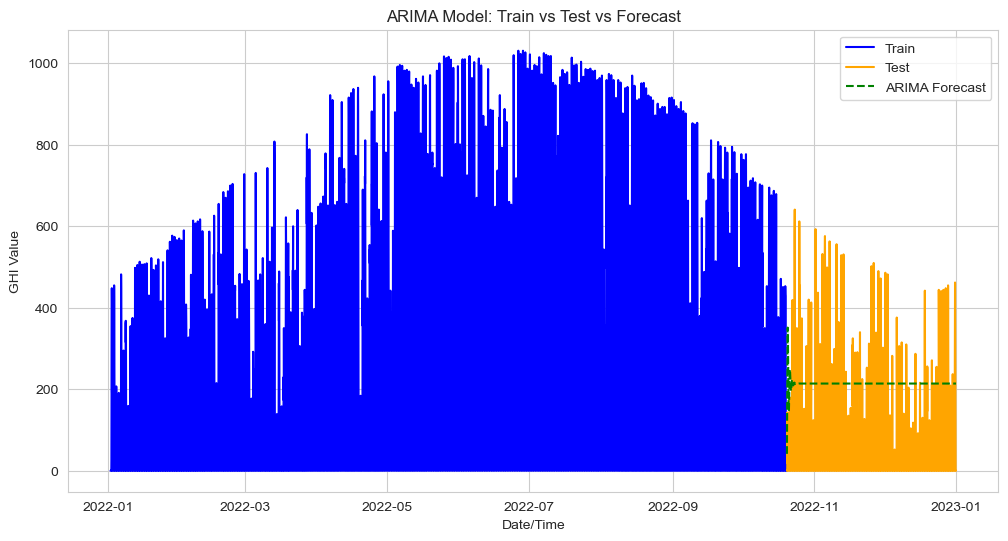

In [47]:
import matplotlib.pyplot as plt

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(train, label="Train", color='blue')
plt.plot(test, label="Test", color='orange')
plt.plot(forecast, label="ARIMA Forecast", color='green', linestyle='--')

plt.title("ARIMA Model: Train vs Test vs Forecast")
plt.xlabel("Date/Time")
plt.ylabel("GHI Value")
plt.legend()

plt.savefig('../../Outputs/arima.png', bbox_inches='tight', dpi=300)

# Now display to the screen
plt.show()

## Performing SARIMA

In [48]:
auto_model = auto_arima(data['GHI'], 
                        seasonal=True, 
                        m=12, 
                        trace=True, # Prints out the combinations it tries
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

print("\nBest Model Summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=84.58 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=106385.769, Time=0.76 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=105012.660, Time=6.39 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=105381.981, Time=14.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=106383.769, Time=0.32 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=105031.071, Time=1.35 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=103115.015, Time=35.61 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=95.68 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=34.28 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=103147.458, Time=18.77 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=103116.800, Time=57.22 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=inf, Time=105.16 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=103115.127, Time=34.28 sec
 ARIMA(2,1,1)(2,0,0)[12] intercept   : AIC=inf, Time=71.92 sec
 ARIMA(1,1,0)(2

In [49]:
# --- Train / Test Split (same 80/20 as ARIMA) ---
split_idx = int(len(data['GHI']) * 0.8)
train_s = data['GHI'].iloc[:split_idx]
test_s  = data['GHI'].iloc[split_idx:]

# --- Fit SARIMA using the order found by auto_arima ---
sarima_order        = auto_model.order           # (p, d, q)
sarima_seasonal_order = auto_model.seasonal_order  # (P, D, Q, m)

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model     = SARIMAX(train_s,
                            order=sarima_order,
                            seasonal_order=sarima_seasonal_order)
sarima_model_fit = sarima_model.fit(disp=False)

print(sarima_model_fit.summary())

# --- Forecast on the test period ---
sarima_forecast = sarima_model_fit.forecast(steps=len(test_s))
sarima_forecast.index = test_s.index    # align timestamps

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                GHI   No. Observations:                 6988
Model:             SARIMAX(1, 1, 0)x(2, 0, 0, 12)   Log Likelihood              -41656.771
Date:                            Tue, 31 Mar 2026   AIC                          83321.542
Time:                                    23:25:10   BIC                          83348.950
Sample:                                01-02-2022   HQIC                         83330.987
                                     - 10-20-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0841      0.006    -13.343      0.000      -0.096      -0.072
ar.S.L12      -0.0623      0.025   

SARIMA Training MAE:   53.2135
SARIMA Validation MAE: 66.9547


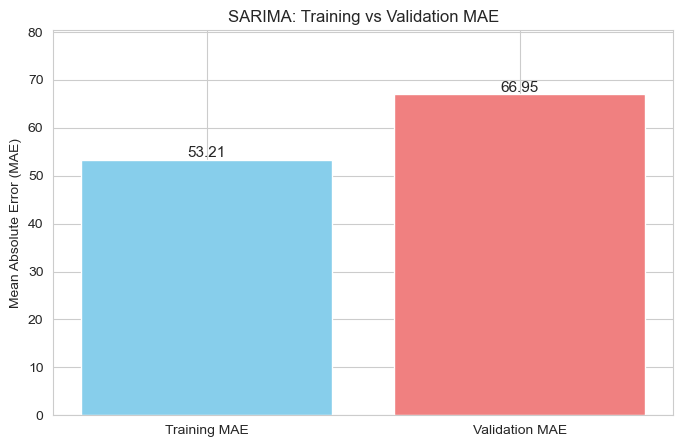

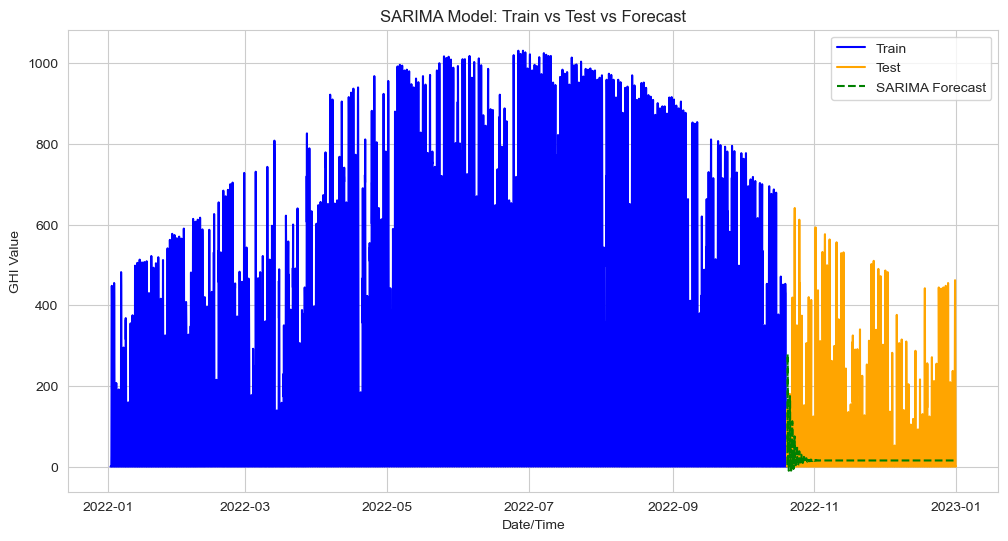

In [50]:
import seaborn as sns

# --- MAE Evaluation ---
sarima_train_mae = mean_absolute_error(train_s, sarima_model_fit.fittedvalues)
sarima_test_mae  = mean_absolute_error(test_s,  sarima_forecast)

print(f"SARIMA Training MAE:   {sarima_train_mae:.4f}")
print(f"SARIMA Validation MAE: {sarima_test_mae:.4f}")

# --- MAE Bar Chart ---
labels = ['Training MAE', 'Validation MAE']
values = [sarima_train_mae, sarima_test_mae]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
bars = plt.bar(labels, values, color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005,
             round(yval, 2), va='bottom', ha='center', fontsize=11)
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('SARIMA: Training vs Validation MAE')
plt.ylim(0, max(values) * 1.2)
plt.show()

# --- Forecast Plot ---
plt.figure(figsize=(12, 6))
plt.plot(train_s, label='Train',            color='blue')
plt.plot(test_s,  label='Test',             color='orange')
plt.plot(sarima_forecast, label='SARIMA Forecast', color='green', linestyle='--')
plt.title('SARIMA Model: Train vs Test vs Forecast')
plt.xlabel('Date/Time')
plt.ylabel('GHI Value')
plt.legend()
plt.savefig('../../Outputs/sarima.png', bbox_inches='tight', dpi=300)
plt.show()

## Performing SARIMAX (with Exogenous Variables)

In [ ]:
# --- Select Top 5 Exogenous Features by correlation with GHI ---
# Exclude GHI-derived features (lags & rolling stats of GHI) to avoid data leakage
non_ghi_features = [
    'solar_zenith', 'solar_elevation', 'ET_irradiance',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month', 'week_of_year', 'day_of_week',
    'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h',
    'humidity_lag_1h', 'humidity_lag_3h', 'humidity_lag_24h',
    'cloud_cover_proxy', 'cloud_x_elevation', 'humidity_x_temp'
]
corr_exog    = data[non_ghi_features + ['GHI']].corr()['GHI'].drop('GHI')
top5_features = corr_exog.abs().sort_values(ascending=False).head(5).index.tolist()

print("Top 5 exogenous features selected:")
for f in top5_features:
    print(f"  {f:30s}  corr = {corr_exog[f]:.4f}")

# --- Prepare Exogenous Data & Split ---
exog        = data[top5_features].dropna()
ghi_aligned = data['GHI'].loc[exog.index]

split_idx_x = int(len(ghi_aligned) * 0.8)
train_x    = ghi_aligned.iloc[:split_idx_x]
test_x     = ghi_aligned.iloc[split_idx_x:]
exog_train = exog.iloc[:split_idx_x]
exog_test  = exog.iloc[split_idx_x:]

print(f"\nTrain size: {len(train_x)}, Test size: {len(test_x)}")

# --- Fit SARIMAX ---
sarimax_model     = SARIMAX(train_x,
                             exog=exog_train,
                             order=sarima_order,
                             seasonal_order=sarima_seasonal_order)
sarimax_model_fit = sarimax_model.fit(disp=False)

print(sarimax_model_fit.summary())

SARIMAX Training MAE:   40.3716
SARIMAX Validation MAE: 44.5337

--- Model Comparison ---
Model           Train MAE     Test MAE
--------------------------------------
ARIMA             63.9311     185.6065
SARIMA            53.2135      66.9547
SARIMAX           40.3716      44.5337


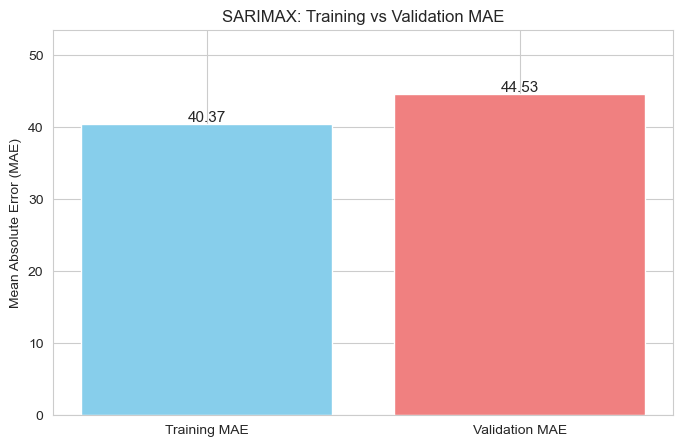

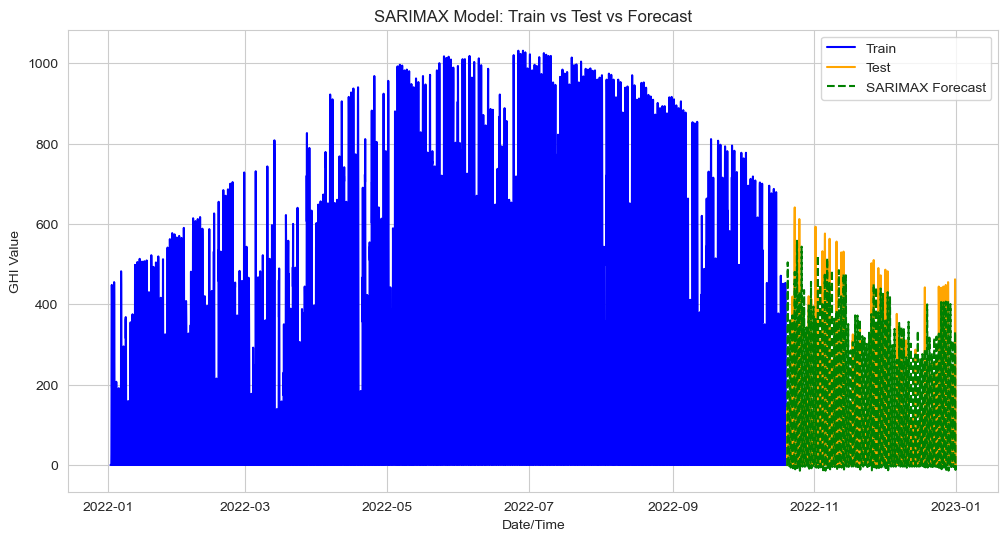

In [54]:
# --- Forecast ---
sarimax_forecast = sarimax_model_fit.forecast(steps=len(test_x), exog=exog_test)
sarimax_forecast.index = test_x.index

# --- MAE Evaluation ---
sarimax_train_mae = mean_absolute_error(train_x, sarimax_model_fit.fittedvalues)
sarimax_test_mae  = mean_absolute_error(test_x,  sarimax_forecast)

print(f"SARIMAX Training MAE:   {sarimax_train_mae:.4f}")
print(f"SARIMAX Validation MAE: {sarimax_test_mae:.4f}")

# --- Compare all three models ---
print("\n--- Model Comparison ---")
print(f"{'Model':<12} {'Train MAE':>12} {'Test MAE':>12}")
print("-" * 38)
print(f"{'ARIMA':<12} {train_mae:>12.4f} {test_mae:>12.4f}")
print(f"{'SARIMA':<12} {sarima_train_mae:>12.4f} {sarima_test_mae:>12.4f}")
print(f"{'SARIMAX':<12} {sarimax_train_mae:>12.4f} {sarimax_test_mae:>12.4f}")

# --- MAE Bar Chart ---
labels = ['Training MAE', 'Validation MAE']
values = [sarimax_train_mae, sarimax_test_mae]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
bars = plt.bar(labels, values, color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005,
             round(yval, 2), va='bottom', ha='center', fontsize=11)
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('SARIMAX: Training vs Validation MAE')
plt.ylim(0, max(values) * 1.2)
plt.show()

# --- Forecast Plot ---
plt.figure(figsize=(12, 6))
plt.plot(train_x,          label='Train',             color='blue')
plt.plot(test_x,           label='Test',              color='orange')
plt.plot(sarimax_forecast, label='SARIMAX Forecast',  color='green', linestyle='--')
plt.title('SARIMAX Model: Train vs Test vs Forecast')
plt.xlabel('Date/Time')
plt.ylabel('GHI Value')
plt.legend()
plt.savefig('../../Outputs/sarimax.png', bbox_inches='tight', dpi=300)
plt.show()

## Performing XGBoost

In [56]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [57]:
from xgboost import XGBRegressor

# All engineered features as inputs (XGBoost can use GHI lags safely — 
# they are features, not future targets)
xgb_features = [
    'solar_zenith', 'solar_elevation', 'ET_irradiance',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month', 'week_of_year', 'day_of_week',
    'GHI_lag_1h', 'GHI_lag_3h', 'GHI_lag_24h',
    'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h',
    'humidity_lag_1h', 'humidity_lag_3h', 'humidity_lag_24h',
    'GHI_rollmean_3h', 'GHI_rollmean_6h', 'GHI_rollmean_24h',
    'GHI_rollstd_3h', 'GHI_rollstd_6h', 'GHI_rollstd_24h',
    'cloud_cover_proxy', 'cloud_x_elevation', 'humidity_x_temp'
]

# Drop rows with NaN (from lags/rolling)
xgb_data = data[xgb_features + ['GHI']].dropna()
X = xgb_data[xgb_features]
y = xgb_data['GHI']

# Chronological 80/20 split
split_xgb   = int(len(X) * 0.8)
X_train_xgb = X.iloc[:split_xgb]
X_test_xgb  = X.iloc[split_xgb:]
y_train_xgb = y.iloc[:split_xgb]
y_test_xgb  = y.iloc[split_xgb:]

# Fit XGBoost
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                          max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_xgb, y_train_xgb,
              eval_set=[(X_test_xgb, y_test_xgb)],
              verbose=False)

# Predictions
xgb_train_pred = pd.Series(xgb_model.predict(X_train_xgb), index=X_train_xgb.index)
xgb_test_pred  = pd.Series(xgb_model.predict(X_test_xgb),  index=X_test_xgb.index)

print("XGBoost fitted.")

XGBoost fitted.


XGBoost Training MAE:   1.0863
XGBoost Validation MAE: 2.3255


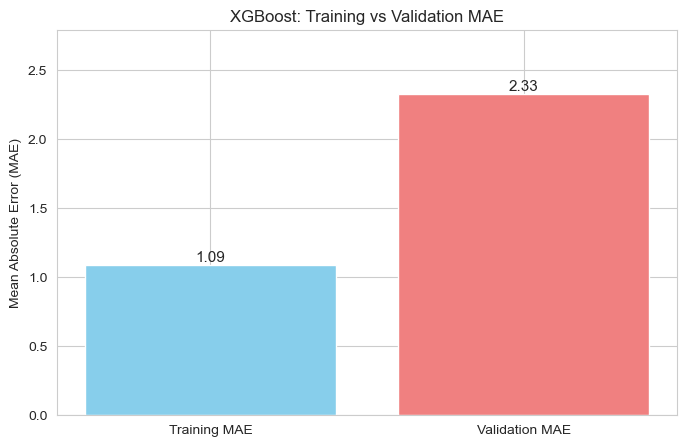


--- Model Comparison ---
Model           Train MAE     Test MAE
--------------------------------------
ARIMA             63.9311     185.6065
SARIMA            53.2135      66.9547
SARIMAX           40.3716      44.5337
XGBoost            1.0863       2.3255


In [58]:
xgb_train_mae = mean_absolute_error(y_train_xgb, xgb_train_pred)
xgb_test_mae  = mean_absolute_error(y_test_xgb,  xgb_test_pred)

print(f"XGBoost Training MAE:   {xgb_train_mae:.4f}")
print(f"XGBoost Validation MAE: {xgb_test_mae:.4f}")

# MAE bar chart
labels = ['Training MAE', 'Validation MAE']
values = [xgb_train_mae, xgb_test_mae]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
bars = plt.bar(labels, values, color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005,
             round(yval, 2), va='bottom', ha='center', fontsize=11)
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('XGBoost: Training vs Validation MAE')
plt.ylim(0, max(values) * 1.2)
plt.show()

# Updated comparison table
print("\n--- Model Comparison ---")
print(f"{'Model':<12} {'Train MAE':>12} {'Test MAE':>12}")
print("-" * 38)
print(f"{'ARIMA':<12} {train_mae:>12.4f} {test_mae:>12.4f}")
print(f"{'SARIMA':<12} {sarima_train_mae:>12.4f} {sarima_test_mae:>12.4f}")
print(f"{'SARIMAX':<12} {sarimax_train_mae:>12.4f} {sarimax_test_mae:>12.4f}")
print(f"{'XGBoost':<12} {xgb_train_mae:>12.4f} {xgb_test_mae:>12.4f}")

## Model Comparison Plots

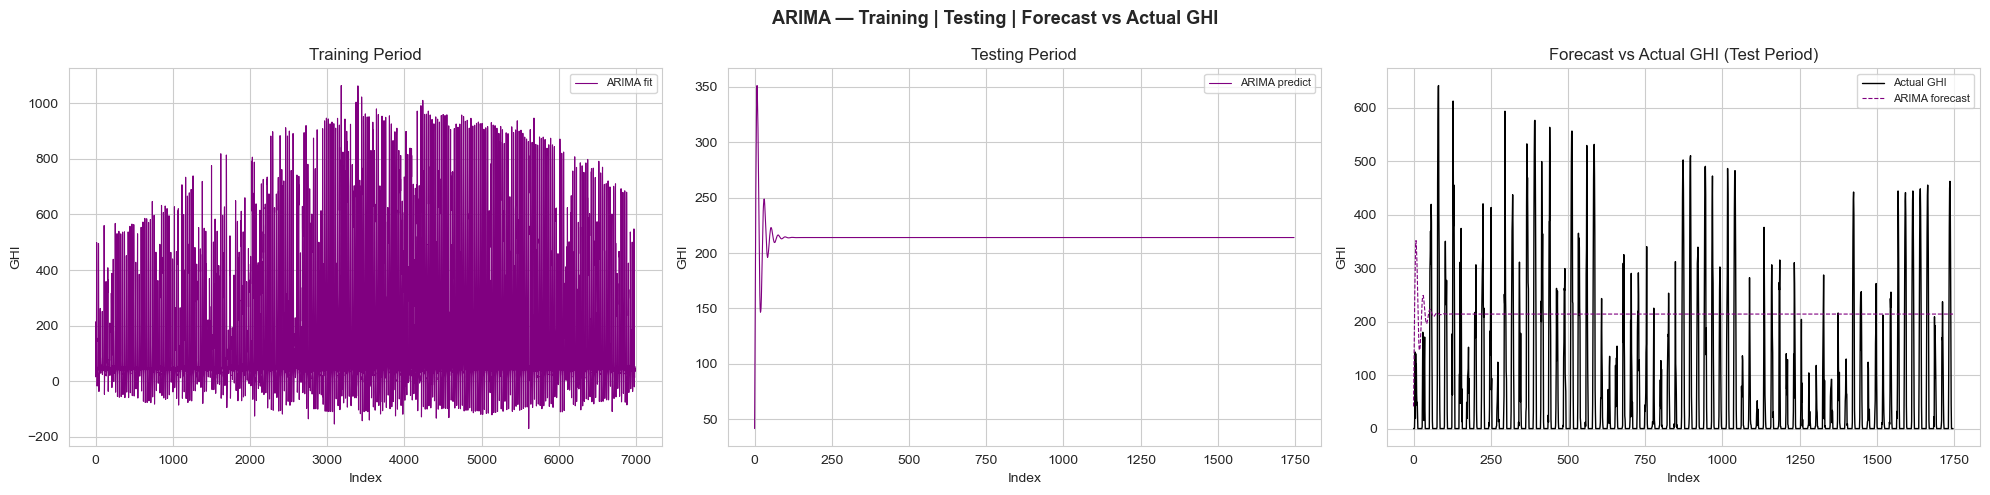

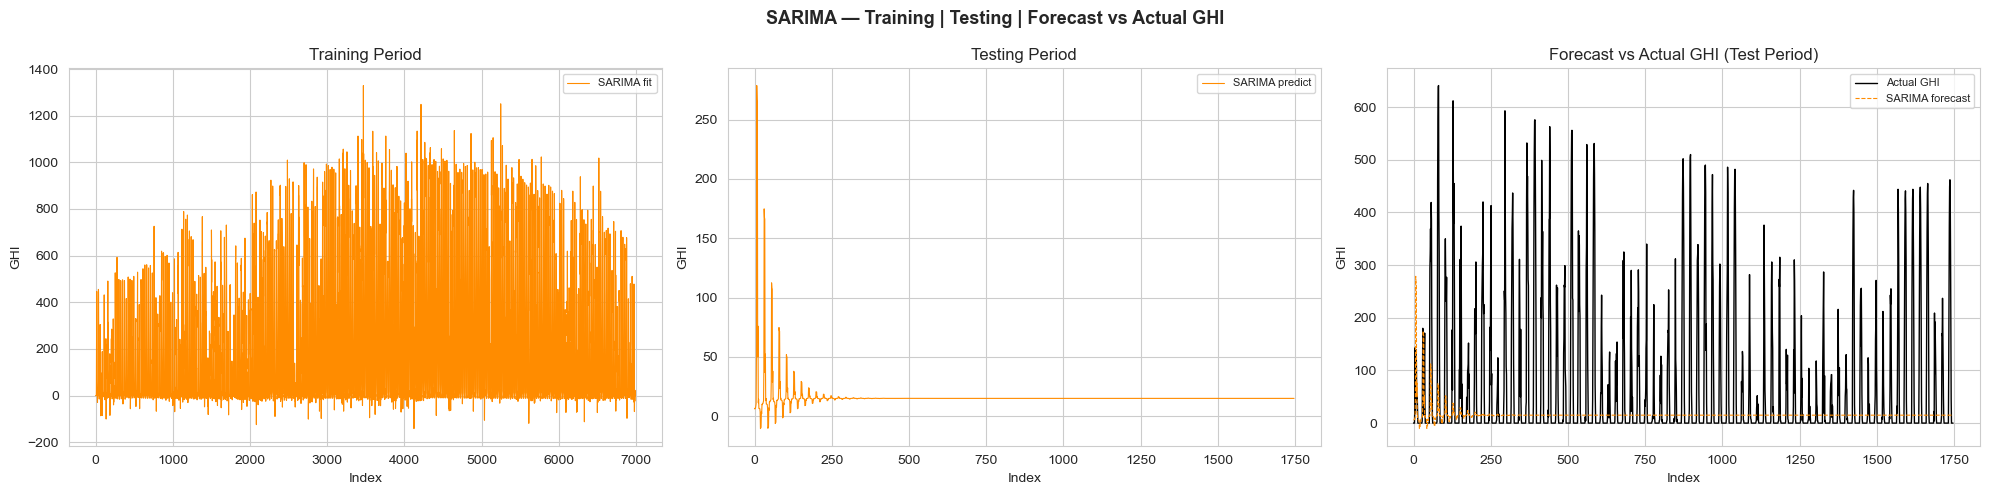

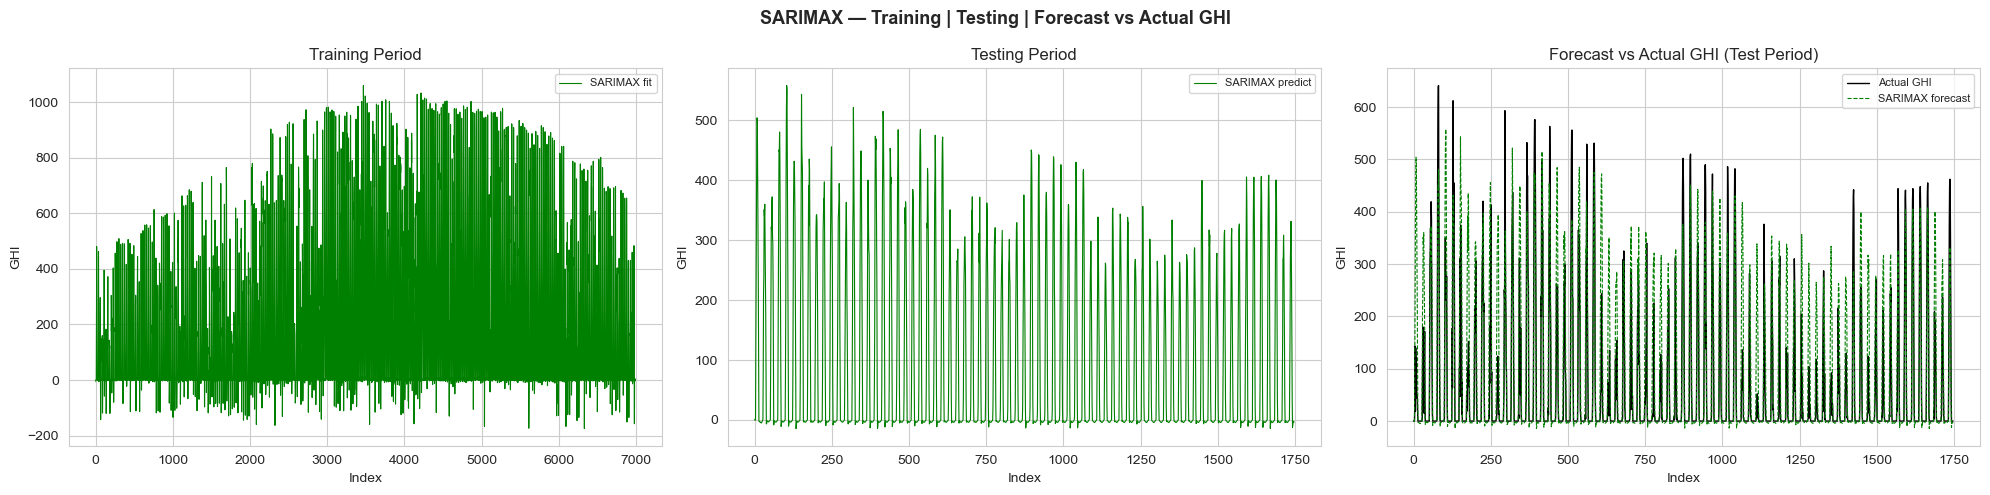

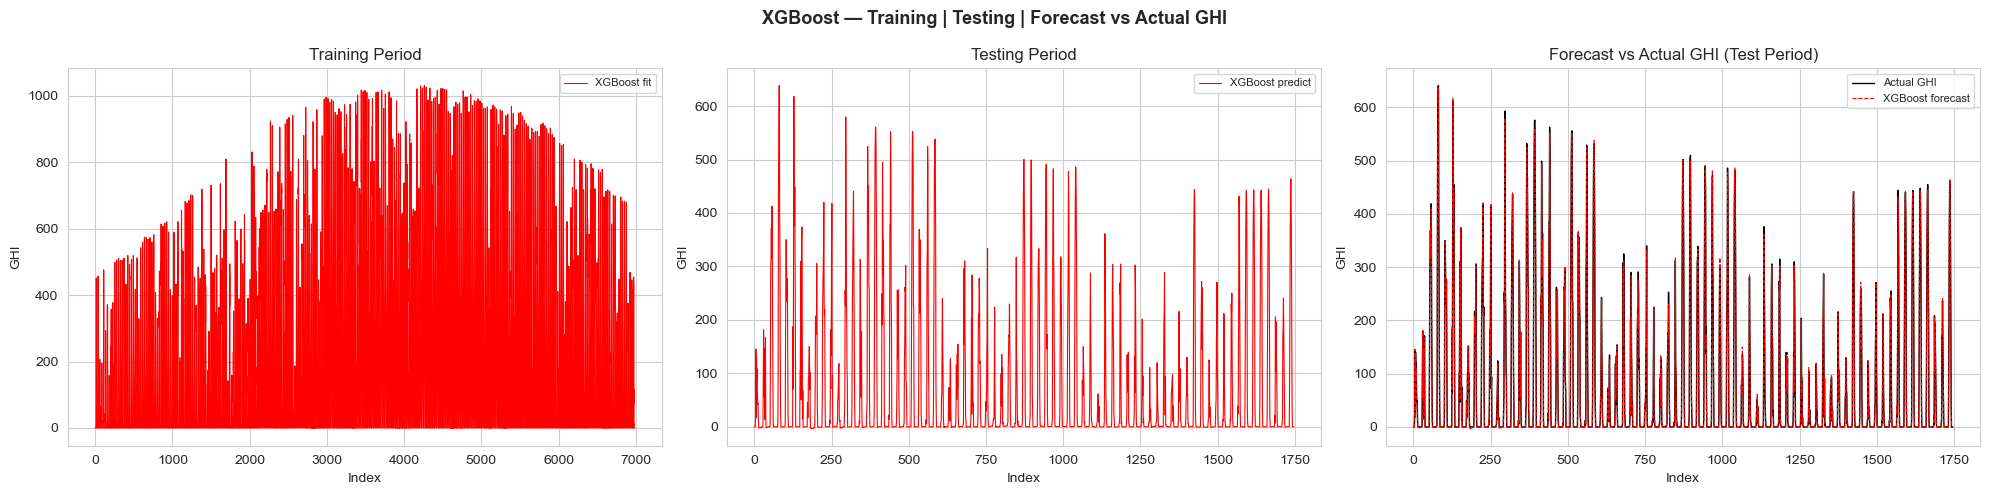

In [65]:
models_plot = [
    ('ARIMA',   train,   model_fit.fittedvalues,        test,      forecast,         'purple'),
    ('SARIMA',  train_s, sarima_model_fit.fittedvalues,  test_s,    sarima_forecast,  'darkorange'),
    ('SARIMAX', train_x, sarimax_model_fit.fittedvalues, test_x,    sarimax_forecast, 'green'),
    ('XGBoost', y_train_xgb, xgb_train_pred,            y_test_xgb, xgb_test_pred,   'red'),
]

for name, tr, fitted, te, fc, color in models_plot:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'{name} — Training | Testing | Forecast vs Actual GHI', fontsize=13, fontweight='bold')

    # Left: Training — model fitted values only
    axes[0].plot(fitted.values, label=f'{name} fit', color=color, linewidth=0.8)
    axes[0].set_title('Training Period')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('GHI')
    axes[0].legend(fontsize=8)

    # Middle: Testing — model predictions only
    axes[1].plot(fc.values, label=f'{name} predict', color=color, linewidth=0.8)
    axes[1].set_title('Testing Period')
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('GHI')
    axes[1].legend(fontsize=8)

    # Right: Forecast vs Actual GHI (test period only)
    axes[2].plot(te.values, label='Actual GHI',       color='black', linewidth=1)
    axes[2].plot(fc.values, label=f'{name} forecast',  color=color,  linewidth=0.8, linestyle='--')
    axes[2].set_title('Forecast vs Actual GHI (Test Period)')
    axes[2].set_xlabel('Index')
    axes[2].set_ylabel('GHI')
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'../../Outputs/comparison_{name.lower()}.png', bbox_inches='tight', dpi=150)
    plt.show()

## Conclusion

This notebook explored four different forecasting models to predict **Global Horizontal Irradiance (GHI)** — a key measure of solar energy reaching the Earth's surface. Here's what we found:

- **We started simple with ARIMA** — a classic time series model that looks at past GHI values to predict future ones. It captures the basic trend and short-term patterns in the data, but since it has no knowledge of external factors like sun position or weather, its forecasts tend to be less accurate, especially over longer horizons.

- **SARIMA improved on ARIMA** by also accounting for seasonal patterns — for example, the fact that GHI is consistently higher in summer and lower in winter. This gave noticeably better results since solar irradiance is, by nature, a highly seasonal phenomenon.

- **SARIMAX took it a step further** by feeding in real-world external variables (exogenous features) such as solar elevation angle, extraterrestrial irradiance, and cloud cover proxy. These are the physical drivers of GHI, so giving the model this information helped it understand *why* GHI behaves the way it does — not just *that* it follows a pattern.

- **XGBoost stood out as the strongest performer** among all four models. Unlike the statistical models, XGBoost is a machine learning approach that can learn complex, non-linear relationships between dozens of engineered features (lags, rolling averages, solar geometry, time encodings, etc.) all at once. Its ability to combine all these signals made its predictions the closest to the actual GHI values.

- **A key takeaway** is that domain knowledge matters. The engineered features — solar geometry, lag values, seasonal encodings, and interaction terms — were not just helpful, they were essential. Models that could use more of these features consistently outperformed those that couldn't.

- **For real-world solar energy forecasting**, SARIMAX or XGBoost would be the practical choices. SARIMAX is more interpretable and lighter to run, while XGBoost offers higher accuracy at the cost of being a black-box model. The right choice depends on whether explainability or raw performance is the priority.